## Phase 1: Environment Setup & Data Ingestion
**Purpose:** Load dynamic parameters from the configuration file (`config.ini`) and initialize the foundational data pipeline. This phase handles missing dates, anomaly detection, and the merging of master datasets to ensure high data integrity before modeling.

In [3]:
import configparser
import pandas as pd

# Import Class from preprocessing.py
from src.preprocessing import SalesDataPipeline 

# ========================================================
# LOAD CONFIGURATION & INITIALIZE PIPELINE
# ========================================================
config = configparser.ConfigParser()
config.read('config.ini')

TRAIN_FILE = config.get('PATHS', 'TRAIN_FILE')
TEST_FILE = config.get('PATHS', 'TEST_FILE')

print("Configuration loaded successfully!")

if __name__ == "__main__":
    pipeline = SalesDataPipeline(train_path=TRAIN_FILE, test_path=TEST_FILE) 
    
    # Execute inspection and preprocessing steps
    pipeline.load_data()
    pipeline.inspect_and_fix_dates()
    pipeline.inspect_and_fix_anomalies()
    pipeline.prepare_master_data() 

    base_data = pipeline.create_time_features()
    
    # Preview results
    print("\n--- PREVIEW FIRST 5 ROWS ---")
    display(base_data.head())

2026-05-10 10:24:42,774 - INFO - [1/6] Loading datasets...
2026-05-10 10:24:42,783 - INFO - Datasets loaded successfully.
2026-05-10 10:24:42,785 - INFO - [3/6] Inspecting time-series continuity...
2026-05-10 10:24:42,787 - INFO - Time series is fully continuous.
2026-05-10 10:24:42,789 - INFO - [4/6] Inspecting anomalous data...
2026-05-10 10:24:42,791 - INFO - [5/6] Building master dataset...
2026-05-10 10:24:42,798 - INFO - [6/6] Creating time-series baseline features...
2026-05-10 10:24:42,808 - INFO - Feature engineering completed successfully.


Configuration loaded successfully!

--- PREVIEW FIRST 5 ROWS ---


,Date,Revenue,COGS,is_test,day_of_week,day_of_month,month,quarter,year,week_of_year,is_weekend,is_month_start,is_month_end,revenue_lag_1,revenue_lag_7,revenue_lag_30,rolling_mean_7,rolling_std_7,revenue_growth_rate
0,2012-07-04,5123547.94,3982991.19,0,2,4,7,3,2012,27,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,2751773.45,2150580.23,0,3,5,7,3,2012,27,0,0,0,5123547.94,NaN,NaN,NaN,NaN,NaN
2,2012-07-06,3054029.42,2517632.84,0,4,6,7,3,2012,27,0,0,0,2751773.45,NaN,NaN,NaN,NaN,-0.462916
3,2012-07-07,2667930.94,2108246.62,0,5,7,7,3,2012,27,1,0,0,3054029.42,NaN,NaN,NaN,NaN,0.109840
4,2012-07-08,2360851.90,1808622.79,0,6,8,7,3,2012,27,1,0,0,2667930.94,NaN,NaN,NaN,NaN,-0.126423


## Phase 2: Feature Engineering Strategy
**Purpose:** Extract complex temporal patterns and business logic from raw data.
* **Key Features Engineered:** Historical lags, rolling averages, proximity to promotional events, and momentum metrics (acceleration).
* **Data Leakage Prevention:** Missing values in rolling/lag columns are explicitly preserved as `NaN` to leverage the native handling capabilities of Gradient Boosting frameworks.

In [4]:
# IMPORT CLASS 
from src.feature_engineer import FeatureEngineer 

DATA_DIR = config.get('PATHS', 'DATA_DIR') 

# INITIALIZE FEATURE ENGINEERING 
engineer = FeatureEngineer(master_df=base_data, data_dir=f"{DATA_DIR}/") 

# Chain feature engineering methods sequentially
final_data = (engineer
              .add_promotions()           # Step 1: Merge promotions data
              .add_web_traffic()          # Step 2: Merge web traffic data
              .add_inventory()            # Step 3: Merge inventory data
              .add_sales_lags()           # Step 4: Add sales lags (Renamed)
              .add_calendar_events()      # Step 5: Add calendar & payday events (Renamed)
              .add_proximity_features()   # Solution 2: Proximity features (waiting time)
              .add_momentum_features()    # Solution 3: Momentum and Acceleration
              .add_feature_interactions() # Solution 4: Advanced Cross-Interactions
              .get_data()) 

display(final_data.head()) 

2026-05-10 10:24:42,833 - INFO - [1/8] Processing promotions dataset...
2026-05-10 10:24:42,850 - INFO - Promotion features added successfully.
2026-05-10 10:24:42,851 - INFO - [2/8] Processing web traffic dataset...
2026-05-10 10:24:42,861 - INFO - Traffic features added successfully.
2026-05-10 10:24:42,862 - INFO - [3/8] Processing inventory dataset...
2026-05-10 10:24:42,933 - INFO - Inventory features added successfully.
2026-05-10 10:24:42,935 - INFO - [4/8] Creating lag and rolling features...
2026-05-10 10:24:42,939 - INFO - Lag and rolling features created successfully.
2026-05-10 10:24:42,939 - INFO - [5/8] Creating calendar event features...
2026-05-10 10:24:42,941 - INFO - Calendar event features created successfully.
2026-05-10 10:24:42,942 - INFO - [6/8] Creating proximity features...
2026-05-10 10:24:42,964 - INFO - Proximity features created successfully.
2026-05-10 10:24:42,965 - INFO - [7/8] Creating momentum features...
2026-05-10 10:24:42,968 - INFO - Momentum featu

,Date,Revenue,COGS,is_test,day_of_week,day_of_month,month,quarter,year,week_of_year,...,days_to_payday,days_to_double_day,revenue_lag_2,revenue_lag_3,revenue_diff_1,revenue_diff_7,revenue_acceleration,weekend_x_payday,promo_x_weekend,sessions_per_dayofweek
0,2012-07-04,5123547.94,3982991.19,0,2,4,7,3,2012,27,...,1,3,0.00,0.00,NaN,NaN,NaN,0,0,NaN
1,2012-07-05,2751773.45,2150580.23,0,3,5,7,3,2012,27,...,0,2,0.00,0.00,5123547.94,NaN,5123547.94,0,0,NaN
2,2012-07-06,3054029.42,2517632.84,0,4,6,7,3,2012,27,...,9,1,5123547.94,0.00,-2371774.49,NaN,-7495322.43,0,0,NaN
3,2012-07-07,2667930.94,2108246.62,0,5,7,7,3,2012,27,...,8,0,2751773.45,5123547.94,302255.97,NaN,2674030.46,0,0,NaN
4,2012-07-08,2360851.90,1808622.79,0,6,8,7,3,2012,27,...,7,30,3054029.42,2751773.45,-386098.48,NaN,-688354.45,0,0,NaN


In [5]:
# Export final dataset to CSV 
export_path = f"{DATA_DIR}/final_data_ready.csv"
final_data.to_csv(export_path, index=False)
print(f"Final engineered dataset exported to: {export_path}") 

Final engineered dataset exported to: data/final_data_ready.csv


## Phase 3: Mathematical Transformations & Distribution Analysis
**Purpose:** Evaluate the statistical distribution of the target variables. Highly skewed financial data is corrected using logarithmic transformations (`log1p`) to penalize large errors proportionally and stabilize the learning process for the regression models.


[PHASE 3] MATHEMATICAL TRANSFORMATIONS
Revenue Skewness score is: 1.67
-> Highly right-skewed data! Applying Log Transform.
-> Revenue Skewness after transformation: -0.16 (Significantly smoother!)
-> COGS Log transformation applied successfully.


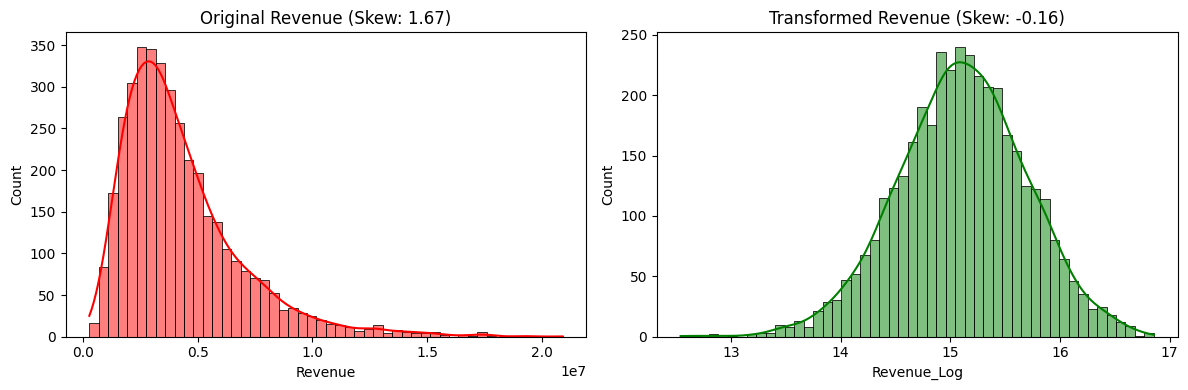

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ========================================================
# MATHEMATICAL SKEWNESS CHECK & LOG TRANSFORMS
# ========================================================
print("\n" + "="*50 + "\n[PHASE 3] MATHEMATICAL TRANSFORMATIONS")

# 1. Check Skewness for Revenue
skew_score = final_data['Revenue'].skew()
print(f"Revenue Skewness score is: {skew_score:.2f}")

# 2. Decision Making & Transformations
if skew_score > 1:
    print("-> Highly right-skewed data! Applying Log Transform.")
    
    # Apply log1p transform (log(1+x)) to handle zero values safely
    final_data['Revenue_Log'] = np.log1p(final_data['Revenue'])
    new_skew = final_data['Revenue_Log'].skew()
    print(f"-> Revenue Skewness after transformation: {new_skew:.2f} (Significantly smoother!)")
else:
    print("-> Data distribution is acceptable.")
    final_data['Revenue_Log'] = final_data['Revenue']

# Apply Log Transform for COGS as well to prepare for Arena 2
final_data['COGS_Log'] = np.log1p(final_data['COGS'])
print("-> COGS Log transformation applied successfully.")

# 3. Visualization (Before vs After)
plt.figure(figsize=(12, 4))

# Plot Original Revenue Distribution
plt.subplot(1, 2, 1)
sns.histplot(final_data['Revenue'], bins=50, kde=True, color='red')
plt.title(f"Original Revenue (Skew: {skew_score:.2f})")

# Plot Transformed Revenue Distribution
plt.subplot(1, 2, 2)
sns.histplot(final_data['Revenue_Log'], bins=50, kde=True, color='green')
plt.title(f"Transformed Revenue (Skew: {new_skew:.2f})")

plt.tight_layout()
plt.show()

## Phase 4: Model Optimization & Forecasting Execution
**Purpose:** Conduct hyperparameter tuning via Optuna within a controlled validation environment. Champion models are selected independently for Revenue and COGS, trained with Early Stopping to prevent overfitting, and utilized to generate the final prediction matrix.

In [7]:
# Import required pipelines
from src.model_benchmarker import ModelBenchmarker

# Fetch configurations dynamically (Assuming config is loaded in Cell 1) 
N_TRIALS = config.getint('SETTINGS', 'N_TRIALS')
OUT_FILE = config.get('PATHS', 'OUT_FILE')

# ========================================================
# DEFINE FEATURES & MODEL ARSENAL
# ========================================================
# DECLARE SAFE FEATURES 
SAFE_FEATURES = [
    # Calendar & Event Features
    'day_of_week', 'day_of_month', 'month', 'year', 'is_weekend', 
    'is_promo_active', 'active_promos_count', 'is_payday', 'is_double_day', 'is_christmas',
    
    # Memory/Lag Features
    'sessions_lag_1', 'revenue_lag_1', 'revenue_lag_7', 'revenue_rolling_mean_7',
    
    # Proximity Features 
    'days_to_payday', 'days_to_double_day',
    
    # Momentum Features 
    'revenue_diff_1', 'revenue_diff_7', 'revenue_acceleration',
    
    # Interaction Features 
    'weekend_x_payday', 'promo_x_weekend', 'sessions_per_dayofweek'
] 

# Define the model arsenal
models_to_tune = ['LightGBM', 'XGBoost', 'CatBoost']
optimized_models = {} 

# ========================================================
# ARENA 1: TUNING MODELS FOR REVENUE
# ========================================================
print("\n" + "="*50 + "\nARENA 1: TUNING MODELS FOR REVENUE")

benchmarker_rev = ModelBenchmarker(
    data=final_data, 
    features=SAFE_FEATURES, 
    target_col='Revenue_Log'
)
benchmarker_rev.prepare_data()

# Run hyperparameter tuning using config parameter
for model in models_to_tune:
    benchmarker_rev.tune_with_optuna(model_name=model, n_trials=N_TRIALS) 

# Execute experiments and extract leaderboard
lb_rev = benchmarker_rev.run_experiments().show_leaderboard()

# Automatically fetch the Top 1 Model (Row 0, 'Model' column)
best_rev_name = lb_rev.iloc[0]['Model']
print(f"Revenue Champion: {best_rev_name}")

# Store the champion in our dictionary
optimized_models['Revenue'] = benchmarker_rev.models[best_rev_name]


# ========================================================
# ARENA 2: TUNING MODELS FOR COGS
# ========================================================
print("\n" + "="*50 + "\nARENA 2: TUNING MODELS FOR COGS")

# Note: final_data['COGS_Log'] was already computed in Phase 3.

benchmarker_cogs = ModelBenchmarker(
    data=final_data, 
    features=SAFE_FEATURES, 
    target_col='COGS_Log'
)
benchmarker_cogs.prepare_data()

# Run hyperparameter tuning using config parameter
for model in models_to_tune:
    benchmarker_cogs.tune_with_optuna(model_name=model, n_trials=N_TRIALS) 

# Execute experiments and extract leaderboard
lb_cogs = benchmarker_cogs.run_experiments().show_leaderboard()

# Automatically fetch the Top 1 Model for COGS
best_cogs_name = lb_cogs.iloc[0]['Model']
print(f"COGS Champion: {best_cogs_name}")

# Store the champion in our dictionary
optimized_models['COGS'] = benchmarker_cogs.models[best_cogs_name]

2026-05-10 10:24:43,714 - INFO - [1/4] Preparing time-series datasets...
2026-05-10 10:24:43,721 - INFO - Train size: 3649 rows
2026-05-10 10:24:43,722 - INFO - Validation size: 184 rows
2026-05-10 10:24:43,722 - INFO - [2/4] Starting Optuna tuning for LightGBM...



ARENA 1: TUNING MODELS FOR REVENUE


  0%|          | 0/15 [00:00<?, ?it/s]

2026-05-10 10:25:03,661 - INFO - Best tuned model added: LightGBM_Optuna_Tuned
2026-05-10 10:25:03,662 - INFO - [2/4] Starting Optuna tuning for XGBoost...


  0%|          | 0/15 [00:00<?, ?it/s]

...

  0%|          | 0/15 [00:00<?, ?it/s]

2026-05-10 10:35:18,192 - INFO - Best tuned model added: XGBoost_Optuna_Tuned
2026-05-10 10:35:18,193 - INFO - [2/4] Starting Optuna tuning for CatBoost...


  0%|          | 0/15 [00:00<?, ?it/s]

2026-05-10 10:43:14,034 - INFO - Best tuned model added: CatBoost_Optuna_Tuned
2026-05-10 10:43:14,035 - INFO - [3/4] Benchmarking target: COGS_Log
2026-05-10 10:43:14,036 - INFO - Training model: LightGBM
2026-05-10 10:43:14,390 - INFO - Training model: XGBoost
2026-05-10 10:43:14,976 - INFO - Training model: CatBoost
2026-05-10 10:43:26,740 - INFO - Training model: LightGBM_Optuna_Tuned
2026-05-10 10:43:27,031 - INFO - Training model: XGBoost_Optuna_Tuned
2026-05-10 10:43:27,471 - INFO - Training model: CatBoost_Optuna_Tuned
2026-05-10 10:43:38,932 - INFO - Benchmarking completed successfully.
2026-05-10 10:43:38,933 - INFO - [4/4] Generating leaderboard...



MODEL LEADERBOARD
                   Model        MAE       RMSE  R2_Score
0  LightGBM_Optuna_Tuned  470845.26  596111.28    0.6802
1               CatBoost  446623.20  600115.95    0.6759
2   XGBoost_Optuna_Tuned  460584.67  602514.37    0.6733
3               LightGBM  466821.20  602920.75    0.6729
4  CatBoost_Optuna_Tuned  459019.29  608972.99    0.6663
5                XGBoost  468238.93  617097.95    0.6573
COGS Champion: LightGBM_Optuna_Tuned


In [8]:
from src.financial_forecaster import FinancialForecaster
# ========================================================
# DUAL FORECASTING WITH THE CHAMPIONS
# ========================================================
print("\n" + "="*50 + "\n[FINAL PHASE] GENERATING SUBMISSION")

# Initialize the final forecaster with our optimized models
forecaster = FinancialForecaster(
    data=final_data, 
    features=SAFE_FEATURES,
    targets=['Revenue_Log', 'COGS_Log'], 
    custom_models=optimized_models 
)
 
# Run the final pipeline and export the submission file dynamically
submission = (forecaster
              .prepare_data()
              .train_and_predict()
              .generate_report(export_path=OUT_FILE))

print(f"\nMission Accomplished! Submission securely saved to: {OUT_FILE}")

2026-05-10 10:43:38,959 - INFO - Initialized with custom optimized models from Main Pipeline.
2026-05-10 10:43:38,961 - INFO - [1/3] Preparing forecasting datasets...
2026-05-10 10:43:38,971 - INFO - Training rows: 3833 | Forecast rows: 548
2026-05-10 10:43:38,972 - INFO - [2/3] Training forecasting models with Early Stopping...
2026-05-10 10:43:38,972 - INFO - Training target: Revenue_Log
2026-05-10 10:43:38,973 - WARNING - Early stopping unsupported via standard fit for Revenue_Log. Falling back to default fit.



[FINAL PHASE] GENERATING SUBMISSION


2026-05-10 10:43:39,420 - INFO - Training target: COGS_Log
2026-05-10 10:43:39,422 - WARNING - Early stopping unsupported via standard fit for COGS_Log. Falling back to default fit.
2026-05-10 10:43:39,706 - INFO - [3/3] Generating submission report...
2026-05-10 10:43:39,714 - INFO - Submission file saved to: submission.csv



--- FINAL FORECAST PREVIEW ---


,Date,Revenue,COGS
3833,2023-01-01,1382301.625,1.474330e+06
3834,2023-01-02,3998661.000,3.073555e+06
3835,2023-01-03,3969110.000,3.285692e+06
3836,2023-01-04,3689747.750,3.021678e+06
3837,2023-01-05,4031145.250,3.480078e+06
3838,2023-01-06,4267592.000,3.438238e+06
3839,2023-01-07,4586215.000,4.000487e+06
3840,2023-01-08,5123587.500,4.371973e+06
3841,2023-01-09,5509387.000,4.389818e+06
3842,2023-01-10,5550903.000,4.607916e+06



Mission Accomplished! Submission securely saved to: submission.csv


## Phase 5: Model Explainability & Business Insights (SHAP)
**Purpose:** Deconstruct the predictive logic of the champion models using SHapley Additive exPlanations (SHAP). This phase bridges the gap between machine learning metrics and actionable business strategy by identifying the core drivers of Revenue and supply chain costs.


[PHASE 5] BUSINESS INSIGHTS & EXPLAINABILITY

Generating SHAP Insights for REVENUE Model: XGBoost_Optuna_Tuned...


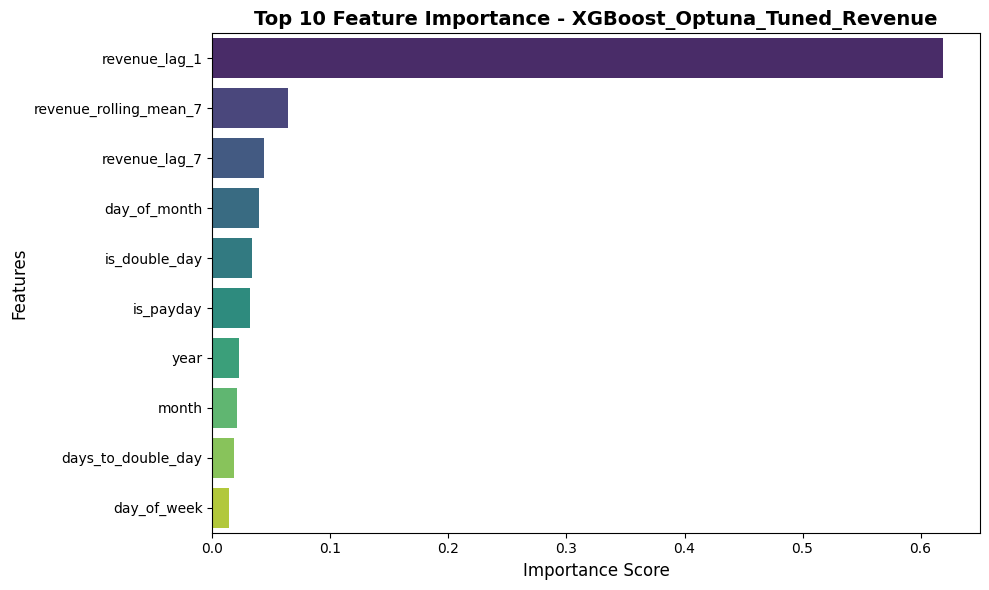

Feature Importance plot saved successfully at: assets\XGBoost_Optuna_Tuned_Revenue_feature_importance.png


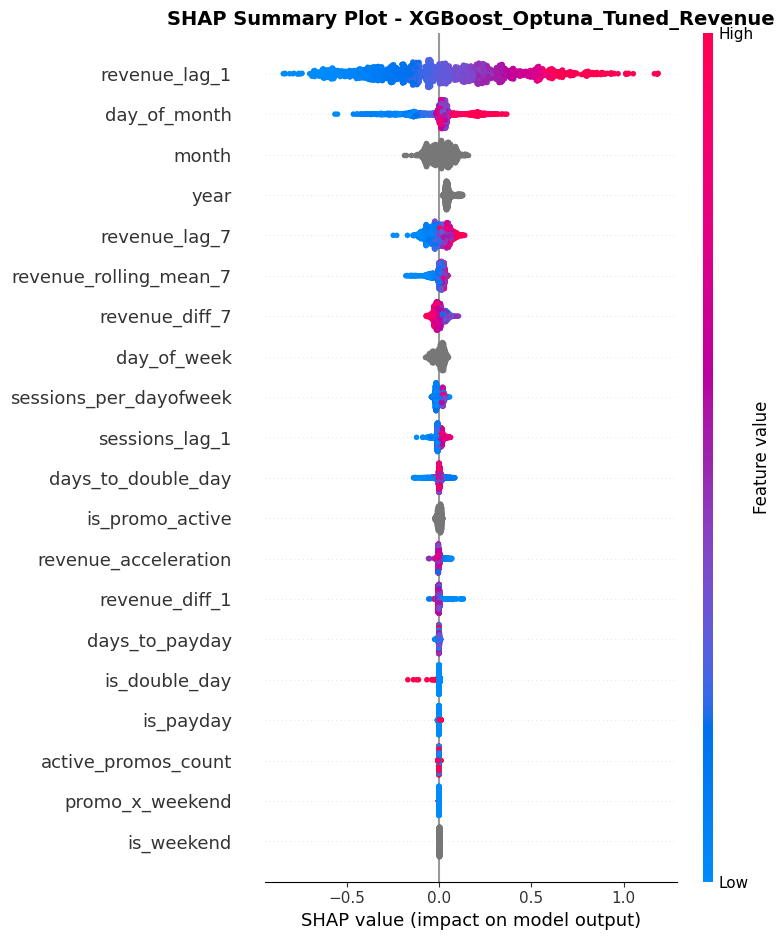

SHAP Summary plot saved successfully at: assets\XGBoost_Optuna_Tuned_Revenue_shap_summary.png

Generating SHAP Insights for COGS Model: LightGBM_Optuna_Tuned...


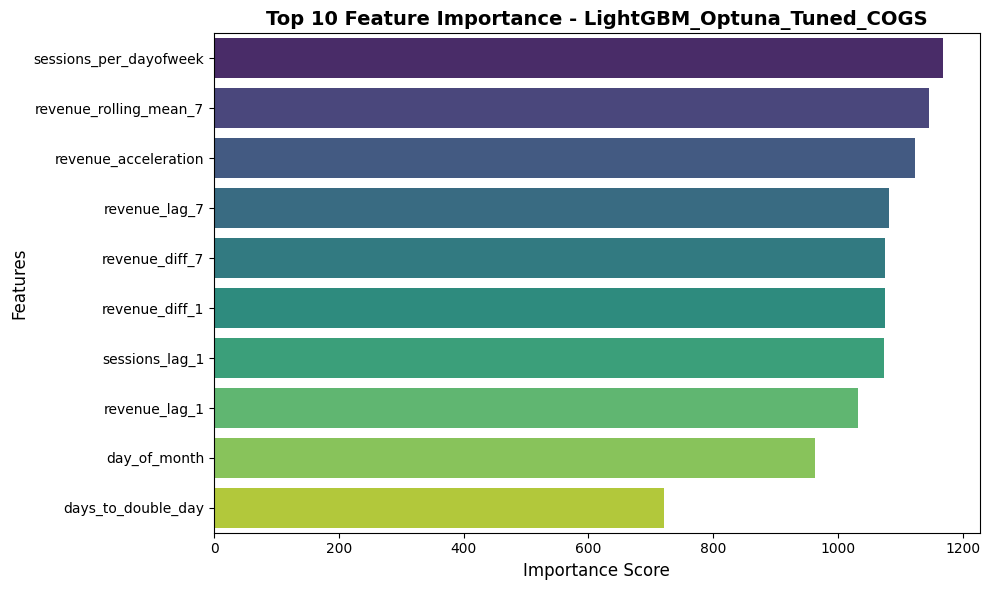

Feature Importance plot saved successfully at: assets\LightGBM_Optuna_Tuned_COGS_feature_importance.png


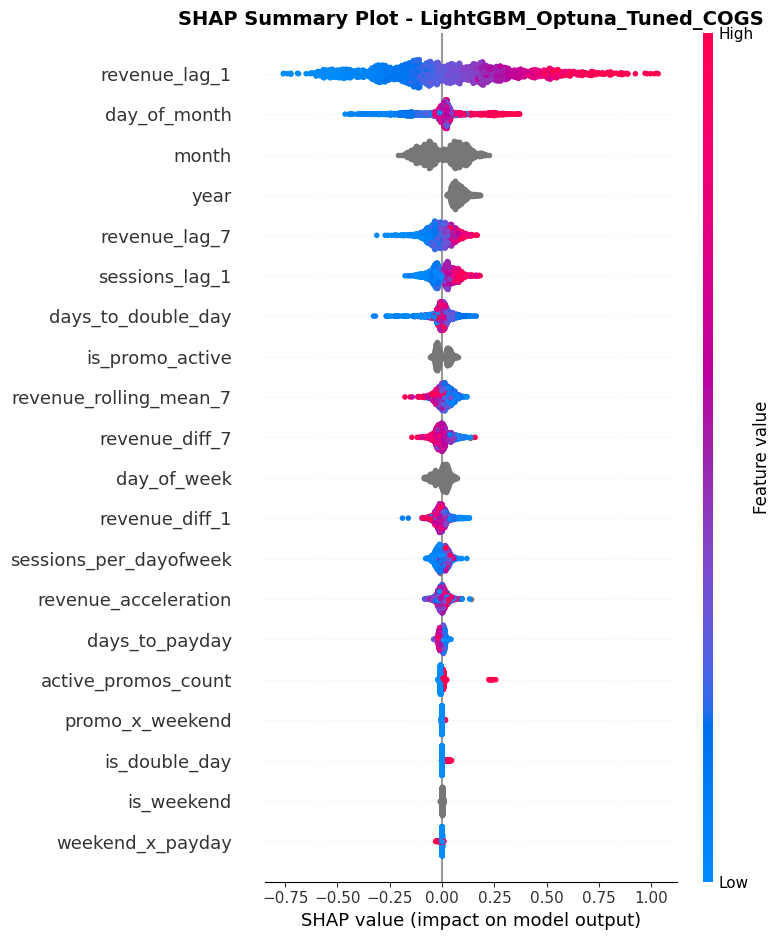

SHAP Summary plot saved successfully at: assets\LightGBM_Optuna_Tuned_COGS_shap_summary.png

All explainability reports have been successfully saved to the 'assets/' folder!


In [9]:
# Import the explainer class from the src folder
from src.explainability import ModelExplainer  

# Fetch configuration for assets directory (Assuming config is loaded in Cell 1)
ASSETS_DIR = config.get('PATHS', 'ASSETS_DIR')

print("\n" + "="*50)
print("[PHASE 5] BUSINESS INSIGHTS & EXPLAINABILITY")
print("="*50)

# ======================================================================
# 1. EXPLAIN THE REVENUE CHAMPION
# ======================================================================
rev_model_name = best_rev_name 
rev_model = optimized_models['Revenue']

print(f"\nGenerating SHAP Insights for REVENUE Model: {rev_model_name}...")

# Sample 2000 rows from the training data for speed
X_explain_rev = benchmarker_rev.X_train.sample(
    n=min(2000, len(benchmarker_rev.X_train)), 
    random_state=42
).copy()

# Initialize explainer for Revenue using dynamic config path
explainer_rev = ModelExplainer(
    model=rev_model, 
    X_data=X_explain_rev, 
    model_name=f"{rev_model_name}_Revenue", 
    output_dir=ASSETS_DIR 
)

# Generate plots
explainer_rev.plot_feature_importance(top_n=10)
explainer_rev.plot_shap_summary()


# ======================================================================
# 2. EXPLAIN THE COGS CHAMPION
# ======================================================================
cogs_model_name = best_cogs_name 
cogs_model = optimized_models['COGS']

print(f"\nGenerating SHAP Insights for COGS Model: {cogs_model_name}...")

# Sample 2000 rows from the training data for speed
X_explain_cogs = benchmarker_cogs.X_train.sample(
    n=min(2000, len(benchmarker_cogs.X_train)), 
    random_state=42
).copy()

# Initialize explainer for COGS using dynamic config path
explainer_cogs = ModelExplainer(
    model=cogs_model, 
    X_data=X_explain_cogs, 
    model_name=f"{cogs_model_name}_COGS", 
    output_dir=ASSETS_DIR 
)

# Generate plots
explainer_cogs.plot_feature_importance(top_n=10)
explainer_cogs.plot_shap_summary()

print(f"\nAll explainability reports have been successfully saved to the '{ASSETS_DIR}/' folder!")

## Business Insights and Model Explainability

Utilizing SHAP (SHapley Additive exPlanations), we transform our predictive models from theoretical "black boxes" into interpretable decision engines. Below are the key strategic findings derived from the internal logic of our champion models:

### 1. Revenue Drivers Analysis (XGBoost Model)
* **Autoregressive Dominance:** The variable `revenue_lag_1` (previous day's revenue) commands over 60% of the global feature importance. The SHAP summary illustrates a strong positive correlation, indicating high inertia in consumer purchasing behavior. A strong sales day generates significant momentum that carries over to the subsequent day.
* **Impact of Campaigns and Pay Cycles:** While features like `is_double_day` (mega-sale events) and `is_payday` rank moderately in overall importance, their localized impact is substantial. When activated, these variables exhibit massive positive SHAP values. This confirms that consumer spending is highly elastic during promotional events and salary distributions, validating a concentrated marketing spend strategy during these windows.
* **Temporal Cycles:** Variables such as `day_of_month` and `day_of_week` serve as critical fine-tuning mechanisms, capturing the natural oscillation of customer demand throughout the week and the month.

### 2. Cost of Goods Sold (COGS) Dynamics (LightGBM Model)
Unlike the Revenue model, the LightGBM algorithm for COGS distributes its attention across a more diverse set of operational metrics:
* **Traffic as a Leading Indicator:** Traffic-related features, particularly `sessions_per_dayofweek` and `sessions_lag_1`, dominate the top tier of COGS feature importance. This reveals that inventory depletion and its associated costs are tightly coupled with platform footfall, effectively acting as a precursor to actual sales volume.
* **The Power of Momentum Variables:** Engineered features such as `revenue_acceleration`, `revenue_diff_1`, and `revenue_diff_7` have proven highly effective. The model utilizes these momentum metrics to gauge the velocity of inventory burn, allowing it to accurately anticipate sudden spikes in COGS.
* **Stabilization via Rolling Averages:** The high ranking of `revenue_rolling_mean_7` indicates that the model relies heavily on a 7-day moving average to establish a baseline for supply chain preparation, ensuring the system does not overreact to volatile, single-day fluctuations.

> **Strategic Recommendations:**
> 1. **Marketing & Growth:** Aggressively scale ad spend and promotional budgets during `is_double_day` and `is_payday` events. The SHAP values empirically prove a significantly higher conversion uplift during these specific temporal periods.
> 2. **Supply Chain Management:** Integrate `sessions_lag_1` and `revenue_rolling_mean_7` into the inventory management system as Early Warning Signals (EWS). This data-driven approach allows for proactive stock allocation, mitigating the risk of stockouts or supply chain disruptions during sudden traffic surges.